In [1]:
from common_helper_functions import *


In [2]:
path = "../../../../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/"

omics = pd.read_csv(path + 'omics_d256.tsv', sep='\t')

string = pd.read_csv(path + 'STRING_d128.tsv', sep='\t')

string_exp = pd.read_csv(path + 'STRING_EXP_d128.tsv', sep='\t')

orthrus = pd.read_csv('../preprocessed_data/orthrus_processed.csv')

emogi = pd.read_csv("../preprocessed_data/emogi_preprocessed.tsv", sep='\t')

# Create emogi predictions as a feature dataset (just the prediction column)
emogi_predictions = emogi[['gene_id', 'pred']].copy()

In [3]:
orthrus_omics = orthrus.merge(omics, on='gene_id', how='inner')
orthrus_string = orthrus.merge(string, on='gene_id', how='inner')
orthrus_string_exp = orthrus.merge(string_exp, on='gene_id', how='inner')
orthrus_emogi = orthrus.merge(emogi, on='gene_id', how='inner')

# Normalize combined datasets with z-scores


In [4]:
orthrus_omics_normalized = orthrus_omics.copy()
numeric_cols = orthrus_omics.select_dtypes(include=[np.number]).columns
orthrus_omics_normalized[numeric_cols] = (orthrus_omics[numeric_cols] - orthrus_omics[numeric_cols].mean()) / orthrus_omics[numeric_cols].std()

orthrus_string_normalized = orthrus_string.copy()
numeric_cols = orthrus_string.select_dtypes(include=[np.number]).columns
orthrus_string_normalized[numeric_cols] = (orthrus_string[numeric_cols] - orthrus_string[numeric_cols].mean()) / orthrus_string[numeric_cols].std()

orthrus_string_exp_normalized = orthrus_string_exp.copy()
numeric_cols = orthrus_string_exp.select_dtypes(include=[np.number]).columns
orthrus_string_exp_normalized[numeric_cols] = (orthrus_string_exp[numeric_cols] - orthrus_string_exp[numeric_cols].mean()) / orthrus_string_exp[numeric_cols].std()

orthrus_emogi_normalized = orthrus_emogi.copy()
numeric_cols = orthrus_emogi.select_dtypes(include=[np.number]).columns
orthrus_emogi_normalized[numeric_cols] = (orthrus_emogi[numeric_cols] - orthrus_emogi[numeric_cols].mean()) / orthrus_emogi[numeric_cols].std()

# Apply PCA

In [5]:
orthrus_omics_pca = pca_reduce(orthrus_omics_normalized, n_components=256)
orthrus_string_pca = pca_reduce(orthrus_string_normalized, n_components=256)
orthrus_string_exp_pca = pca_reduce(orthrus_string_exp_normalized, n_components=256)
orthrus_emogi_pca = pca_reduce(orthrus_emogi_normalized, n_components=256)


# Predictions without PCA

Filtered to 12874 common genes across all datasets.
Omics + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
Omics + Orthrus - RF auPRC: 0.137±0.005, XGB auPRC: 0.165±0.033
STRING + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING + Orthrus - RF auPRC: 0.358±0.037, XGB auPRC: 0.443±0.030
STRING_EXP + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING_EXP + Orthrus - RF auPRC: 0.233±0.024, XGB auPRC: 0.282±0.021
Error processing Orthrus: 'label'

PR Curves Results summary (Mean ± Std):
Model                 Random Forest   XGBoost
Embedding                                    
Omics + Orthrus            0.136940  0.165213
STRING + Orthrus           0.358259  0.443324
STRING_EXP + Orthrus       0.233001  0.282031


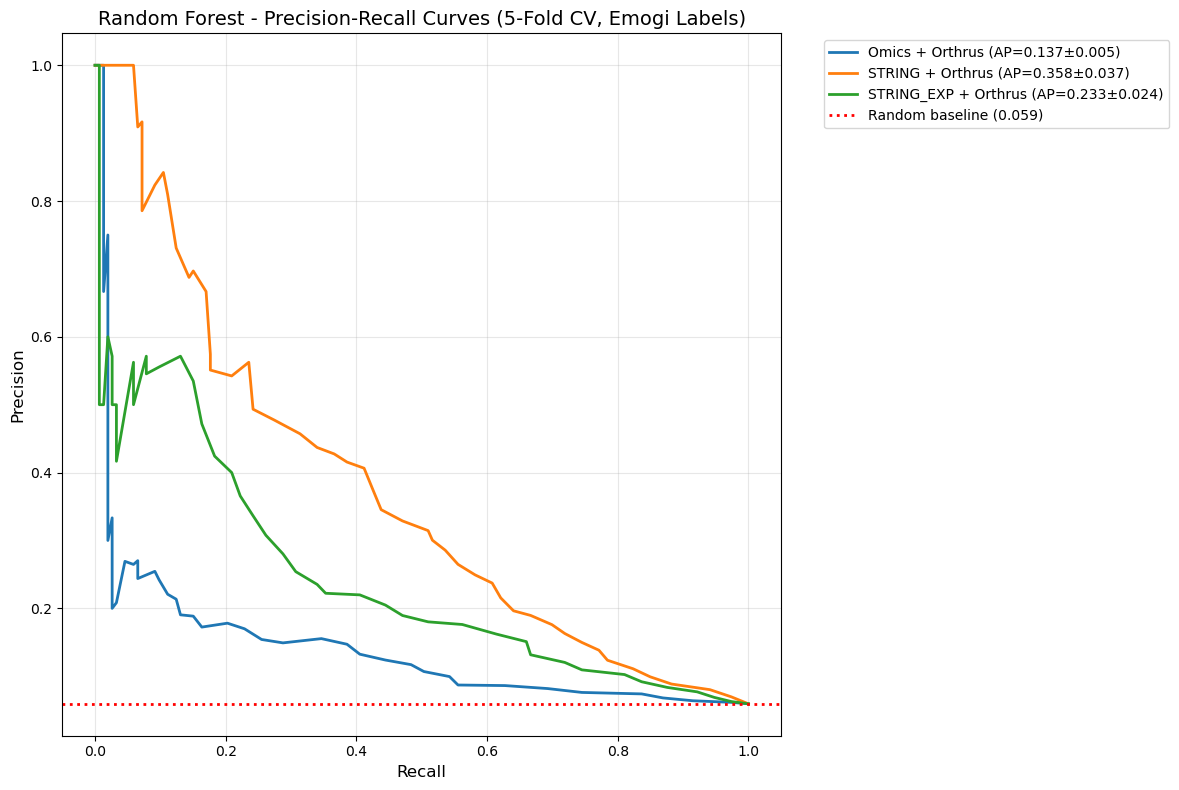

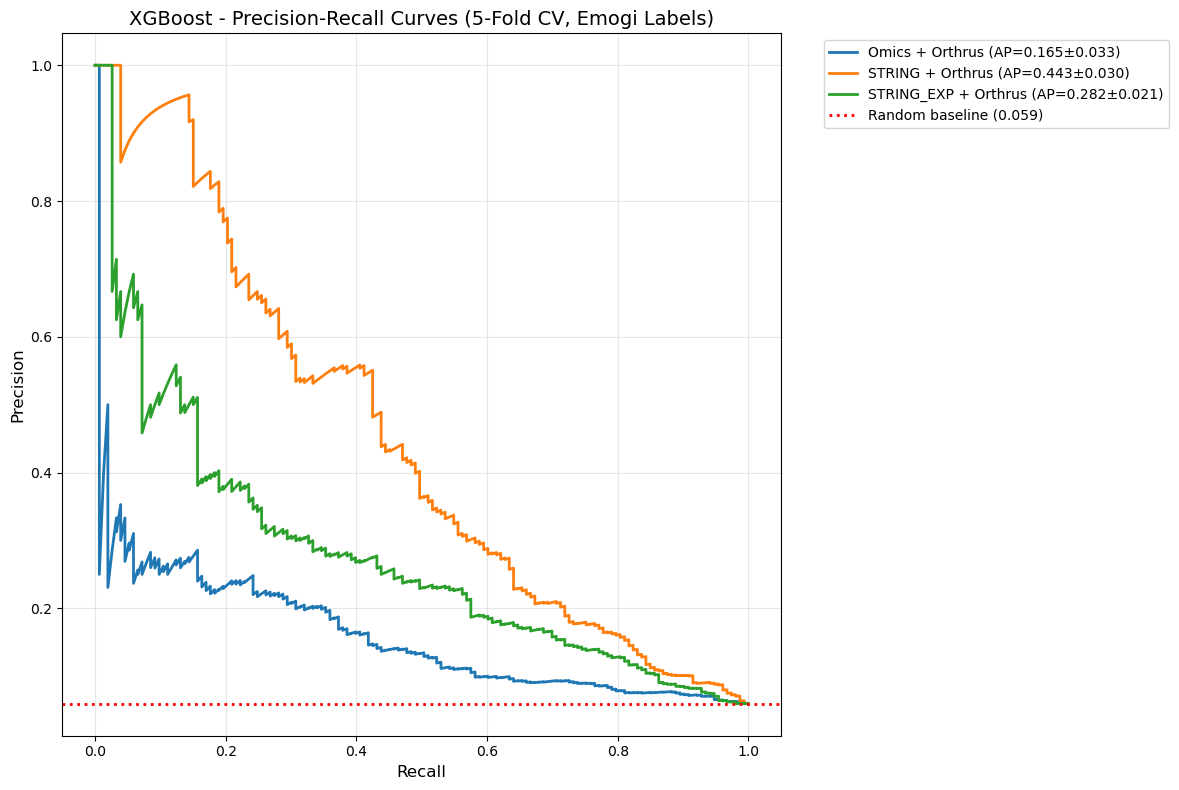

In [6]:
# Define embedding datasets
embedding_datasets = {
    'Omics + Orthrus': orthrus_omics_normalized,
    'STRING + Orthrus': orthrus_string_normalized,
    'STRING_EXP + Orthrus': orthrus_string_exp_normalized,
    'Orthrus': orthrus_emogi_normalized,
}

# PR Curves comparison
results = compare_embeddings_pr_curves(embedding_datasets, emogi, save_plots=False)
print("\nPR Curves Results summary (Mean ± Std):")
print(results.pivot(index='Embedding', columns='Model', values='auPRC'))


Filtered to 12874 common genes across all datasets.
Omics + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)


Omics + Orthrus: RF auPRC=0.137±0.005, XGB auPRC=0.165±0.033
STRING + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING + Orthrus: RF auPRC=0.358±0.037, XGB auPRC=0.443±0.030
STRING_EXP + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING_EXP + Orthrus: RF auPRC=0.233±0.024, XGB auPRC=0.282±0.021
Error processing Orthrus: 'label'

auPRC Bar Plot Results summary (Mean ± Std):
Model                 Random Forest   XGBoost
Embedding                                    
Omics + Orthrus            0.136940  0.165213
STRING + Orthrus           0.358259  0.443324
STRING_EXP + Orthrus       0.233001  0.282031


/data/nasif12/home_if12/kurte/projects/RNA-gene-disease-predictions/Cancer Predictions/common_helper_functions.py:452: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=45, ha='right')
/data/nasif12/home_if12/kurte/projects/RNA-gene-disease-predictions/Cancer Predictions/common_helper_functions.py:452: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=45, ha='right')


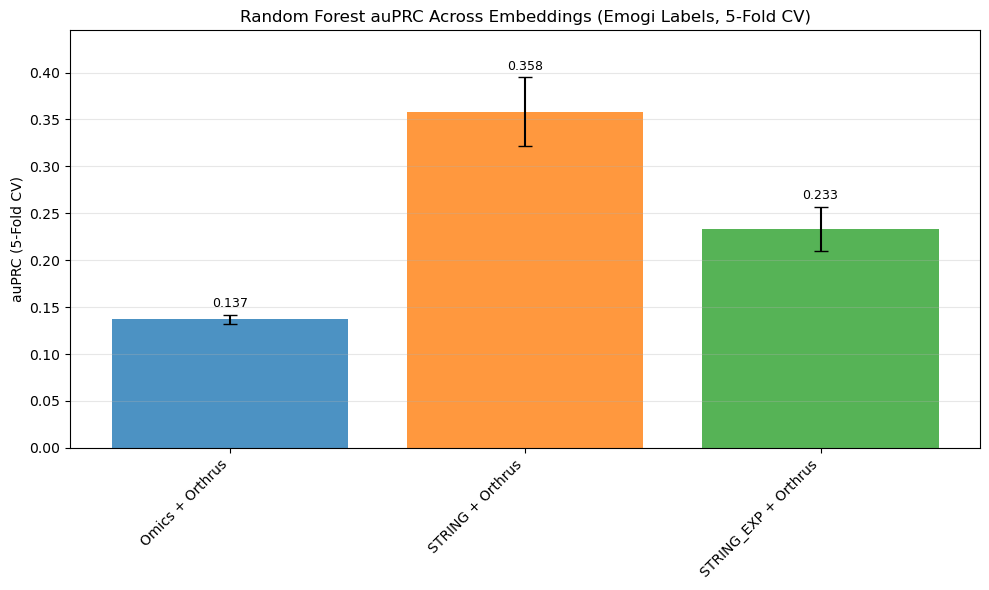

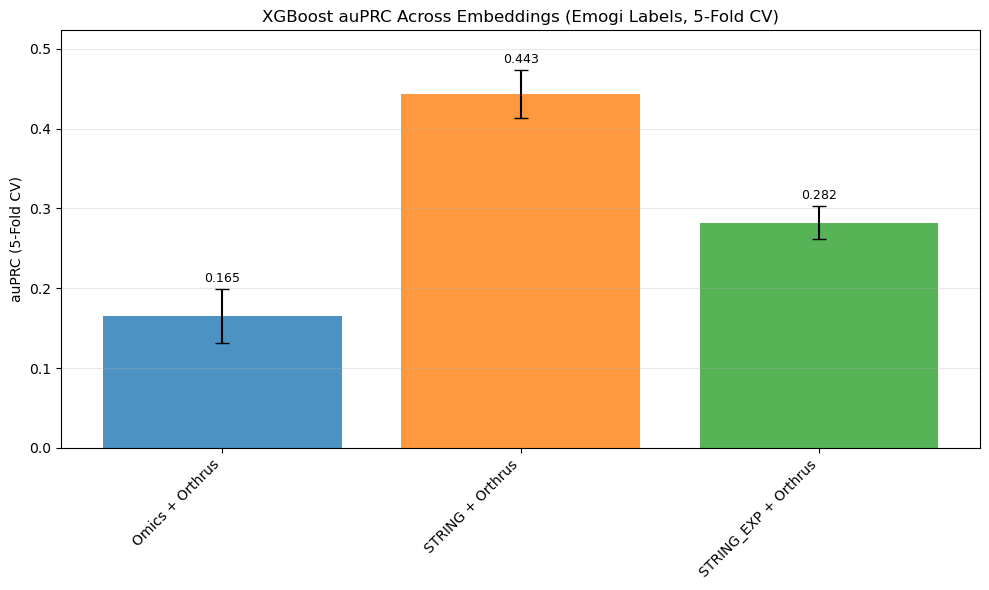

In [7]:
# auPRC bar plots comparison
auprc_results = compare_embeddings_auprc_barplots(embedding_datasets, emogi, save_plots=False)
print("\nauPRC Bar Plot Results summary (Mean ± Std):")
print(auprc_results.pivot(index='Embedding', columns='Model', values='auPRC'))

# Predictions with PCA

Filtered to 12874 common genes across all datasets.
Omics + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
Omics + Orthrus - RF auPRC: 0.101±0.012, XGB auPRC: 0.141±0.013
STRING + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING + Orthrus - RF auPRC: 0.229±0.029, XGB auPRC: 0.400±0.033
STRING_EXP + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING_EXP + Orthrus - RF auPRC: 0.148±0.018, XGB auPRC: 0.272±0.013
Error processing Orthrus: 'label'

PR Curves Results summary (Mean ± Std):
Model                 Random Forest   XGBoost
Embedding                                    
Omics + Orthrus            0.101383  0.141176
STRING + Orthrus           0.229494  0.399622
STRING_EXP + Orthrus       0.147612  0.272187


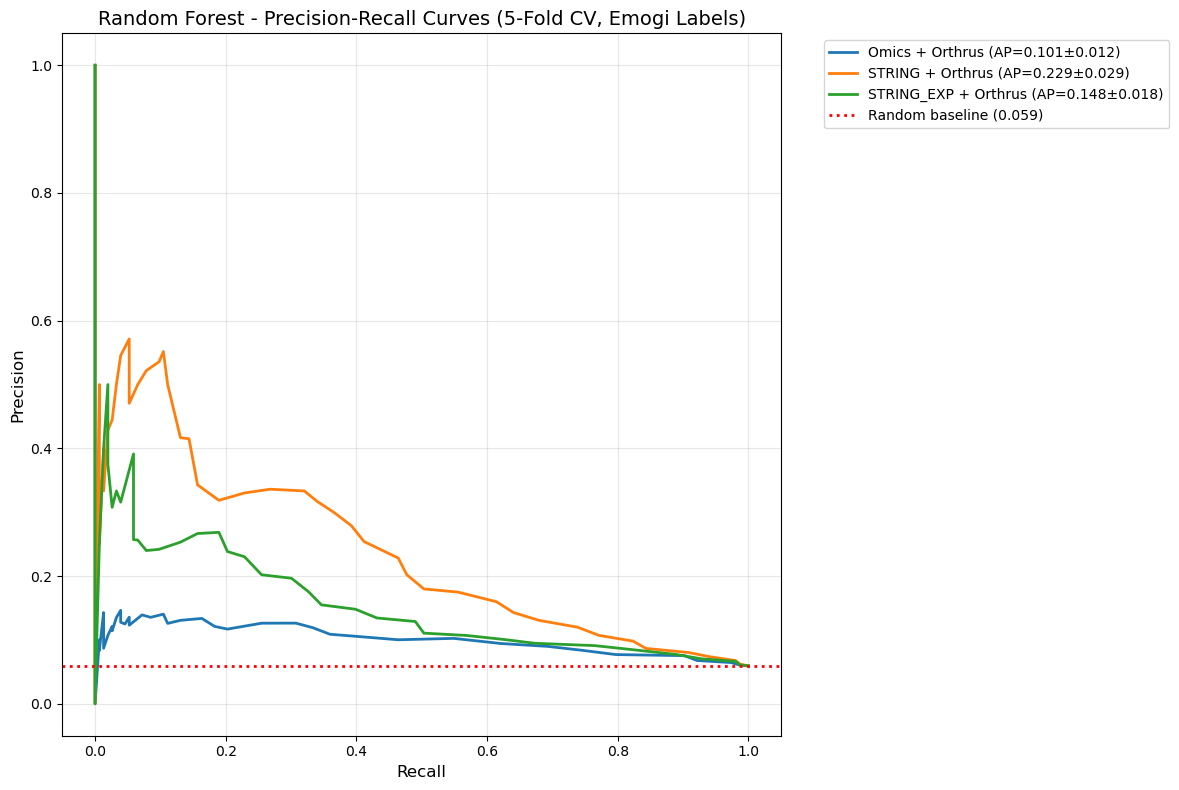

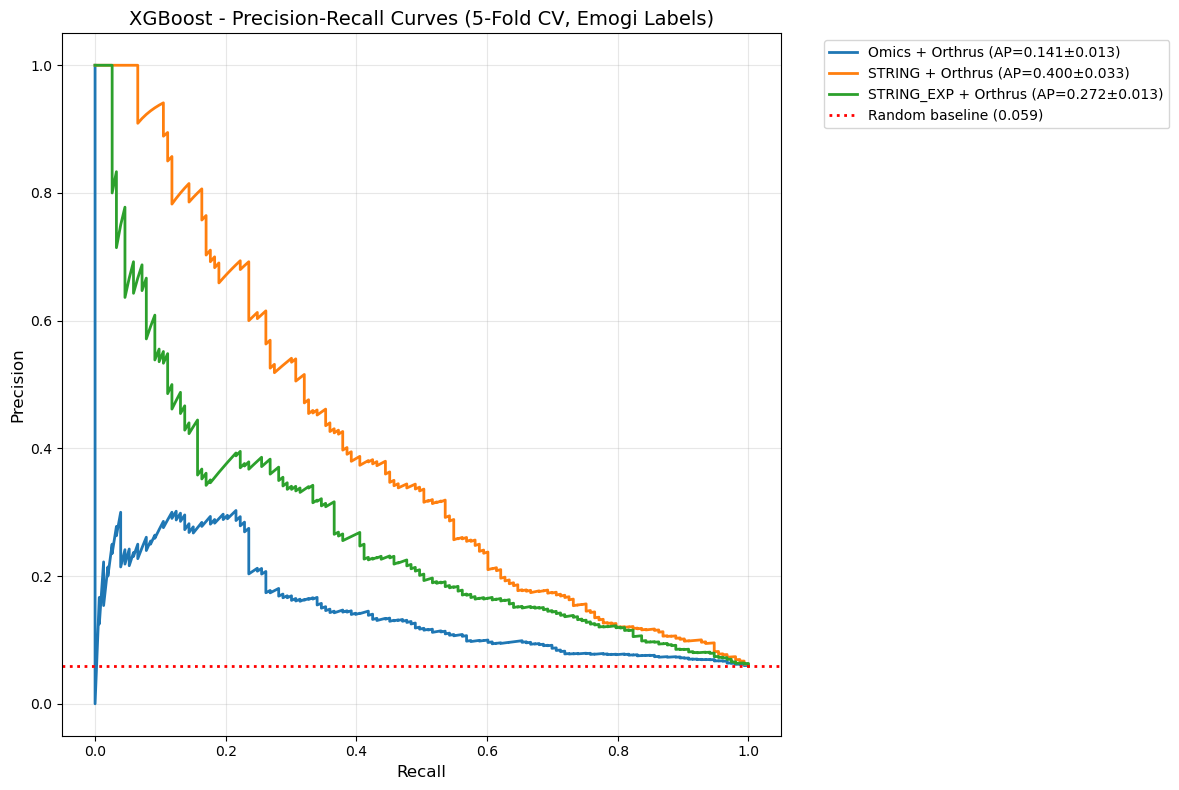

In [8]:
embedding_datasets_pca = {
    'Omics + Orthrus': orthrus_omics_pca,
    'STRING + Orthrus': orthrus_string_pca,
    'STRING_EXP + Orthrus': orthrus_string_exp_pca,
    'Orthrus': orthrus_emogi_pca,
}

results = compare_embeddings_pr_curves(embedding_datasets_pca, emogi, save_plots=False)
print("\nPR Curves Results summary (Mean ± Std):")
print(results.pivot(index='Embedding', columns='Model', values='auPRC'))

Filtered to 12874 common genes across all datasets.
Omics + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
Omics + Orthrus: RF auPRC=0.101±0.012, XGB auPRC=0.141±0.013
STRING + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING + Orthrus: RF auPRC=0.229±0.029, XGB auPRC=0.400±0.033
STRING_EXP + Orthrus: Using 12874 genes (Pos: 764, Neg: 12110)
STRING_EXP + Orthrus: RF auPRC=0.148±0.018, XGB auPRC=0.272±0.013
Error processing Orthrus: 'label'

auPRC Bar Plot Results summary (Mean ± Std):
Model                 Random Forest   XGBoost
Embedding                                    
Omics + Orthrus            0.101383  0.141176
STRING + Orthrus           0.229494  0.399622
STRING_EXP + Orthrus       0.147612  0.272187


/data/nasif12/home_if12/kurte/projects/RNA-gene-disease-predictions/Cancer Predictions/common_helper_functions.py:452: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=45, ha='right')
/data/nasif12/home_if12/kurte/projects/RNA-gene-disease-predictions/Cancer Predictions/common_helper_functions.py:452: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=45, ha='right')


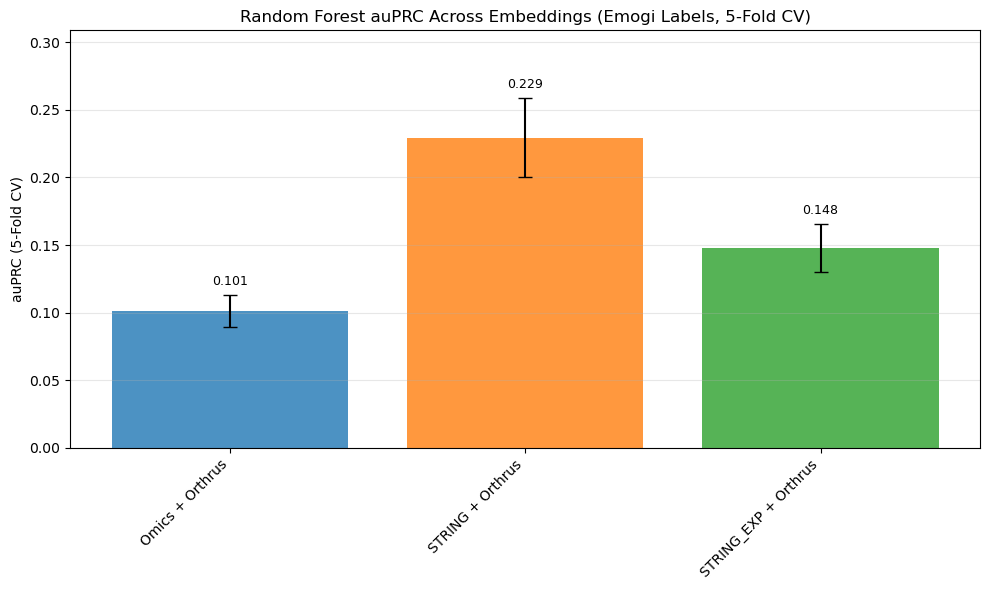

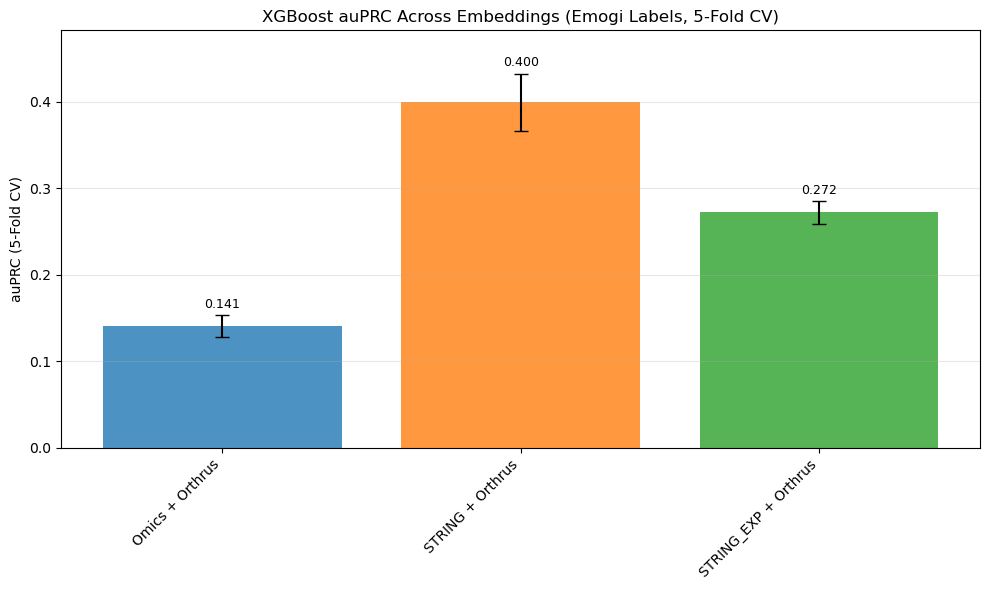

In [9]:
# auPRC bar plots comparison
auprc_results = compare_embeddings_auprc_barplots(embedding_datasets_pca, emogi, save_plots=False)
print("\nauPRC Bar Plot Results summary (Mean ± Std):")
print(auprc_results.pivot(index='Embedding', columns='Model', values='auPRC'))